In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
# Initialize start and end for MCD stock price
begin_at = "2019-11-01"
end_at = "2024-11-01"

data = yf.download("MCD", start=begin_at, end=end_at)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Show data downloaded
data

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MCD,MCD,MCD,MCD,MCD,MCD
Date,,,,,,
2019-11-01,171.639908,193.940002,197.970001,193.699997,197.779999,4192400
2019-11-04,166.967041,188.660004,190.750000,187.550003,190.160004,17662100
2019-11-05,170.082275,192.179993,193.000000,189.449997,189.649994,10496000
2019-11-06,171.852280,194.179993,195.270004,193.050003,193.300003,6473500
2019-11-07,170.878830,193.080002,196.000000,192.320007,195.720001,4820200
...,...,...,...,...,...,...
2024-10-25,290.860321,292.609985,301.600006,292.200012,301.000000,8863200
2024-10-28,295.015350,296.790009,299.920013,296.540009,299.200012,6656000


In [4]:
# Converting data to csv file
file_name = "MCD_(2019 to 2024).csv"
data.to_csv(file_name)
print(f"MCD data has been downloaded and converted to {file_name}")

MCD data has been downloaded and converted to MCD_(2019 to 2024).csv


In [5]:
# Data stats
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-11-01 to 2024-10-31
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, MCD)  1258 non-null   float64
 1   (Close, MCD)      1258 non-null   float64
 2   (High, MCD)       1258 non-null   float64
 3   (Low, MCD)        1258 non-null   float64
 4   (Open, MCD)       1258 non-null   float64
 5   (Volume, MCD)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


In [6]:
# Check for null values
data.isnull().sum()

Price      Ticker
Adj Close  MCD       0
Close      MCD       0
High       MCD       0
Low        MCD       0
Open       MCD       0
Volume     MCD       0
dtype: int64

In [7]:
# Check for duplicates
duplicate = data[data.duplicated(keep=False)]
print(duplicate)

Empty DataFrame
Columns: [(Adj Close, MCD), (Close, MCD), (High, MCD), (Low, MCD), (Open, MCD), (Volume, MCD)]
Index: []


In [8]:
# Description of data
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MCD,MCD,MCD,MCD,MCD,MCD
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,232.990412,246.796526,248.681550,244.799404,246.757011,3.162441e+06
std,38.859105,34.241629,34.084659,34.389337,34.253108,1.542168e+06
min,122.877373,137.100006,141.710007,124.230003,135.199997,1.047700e+06
25%,199.088406,219.377499,221.032505,217.285004,219.012497,2.272100e+06
50%,236.356903,250.854996,253.135002,248.805000,250.699997,2.813900e+06
75%,263.002968,272.257492,274.364998,269.857513,271.729996,3.521750e+06
max,314.667114,316.559998,317.899994,314.410004,317.130005,1.879200e+07


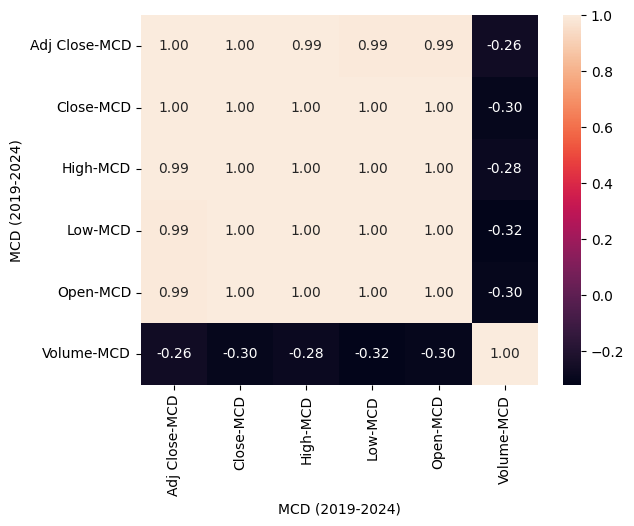

In [9]:
# Correlation matrix
correlation = data.select_dtypes("number").corr()

plt.figure()
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.xlabel("MCD (2019-2024)")
plt.ylabel("MCD (2019-2024)")
plt.show()

Outliers for Adj Close: []
Number of outliers: 0


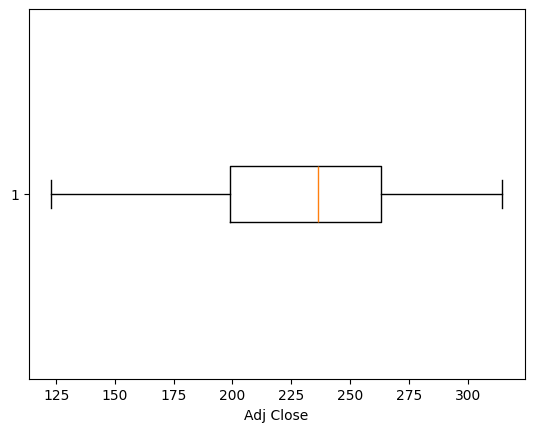

Outliers for Close: [137.30000305 137.1000061 ]
Number of outliers: 2


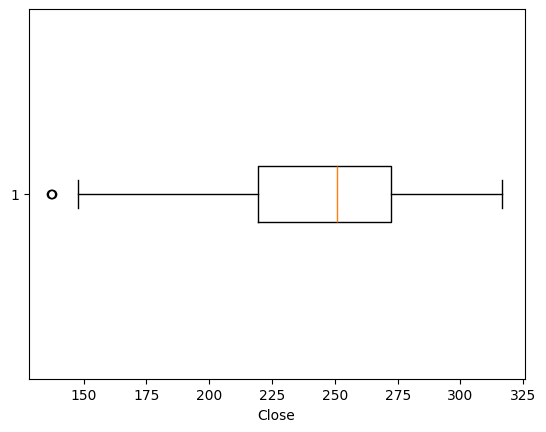

Outliers for High: []
Number of outliers: 0


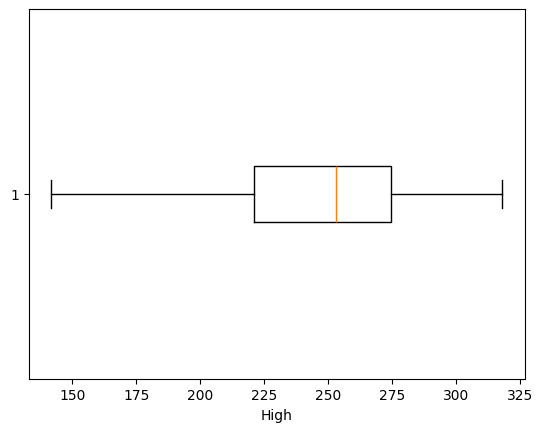

Outliers for Low: [135.         124.23000336 128.21000671 136.5       ]
Number of outliers: 4


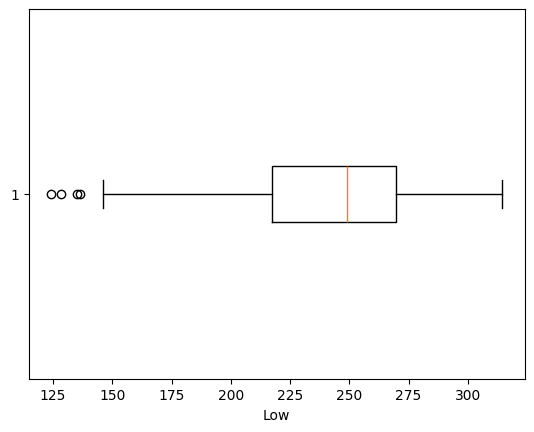

Outliers for Open: [137.5        135.19999695]
Number of outliers: 2


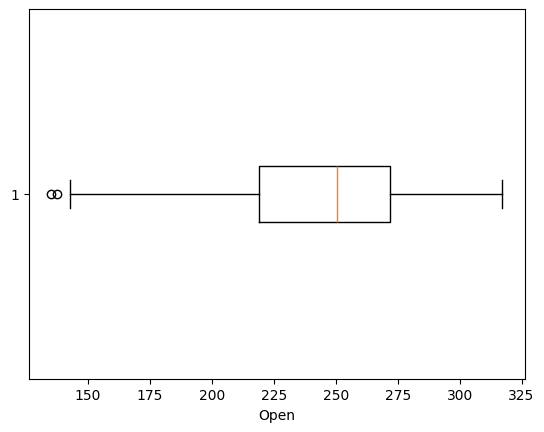

Outliers for Volume: [17662100 10496000  6473500  6415500  5971600  5734800  6406200 11324000
  6154200  6360100  7788500  5835200  5625100  9079300  8042600  9341300
 13708200 12627600 12773400 12000000 10660400 11678400  9708700  8259900
  6441400  5621700  8330900  7848300  5665700  7120800  6467600  7127200
  6879600  5717200  5796000  5434800  6267700  6051000  7981200  6223700
  7929100  5464000  5401600  5479700  7719400  5943200  5425000  5630500
  5444900  6126300  7236300  5429100  5932500  5477900  5845200  5720400
  5646200  6305100  6324300  7581900  5927200  5441300  6815200  6894400
  5636200  6125400  8426600  8958700  5546400  5983300  9381000  9585900
  6794900  5817300  5889100 18792000  5522600  8863200  6656000  9048900]
Number of outliers: 80


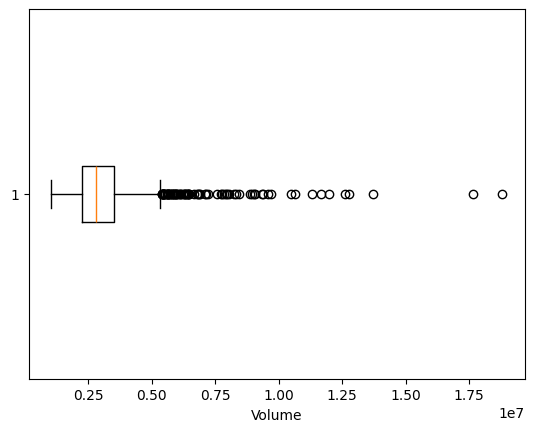

In [10]:
# Boxplots and outlier checking\
outlier = []
for i in ["Adj Close", "Close", "High", "Low", "Open", "Volume"]:
    plt.figure()
    box = plt.boxplot(data[i], vert=False)
    plt.xlabel(i)

    outliers = box["fliers"][0].get_xdata()
    print(f"Outliers for {i}: {outliers}")
    print(f"Number of outliers: {len(outliers)}")

    if len(outliers) > 0:
        outlier.append(outliers)

    plt.show()

Outliers for Open: []
Number of outliers: 0


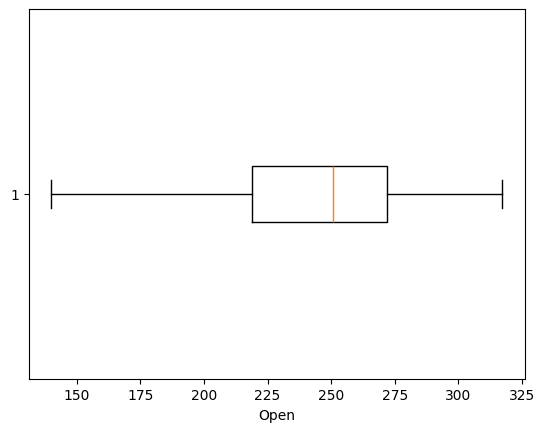

Outliers for High: []
Number of outliers: 0


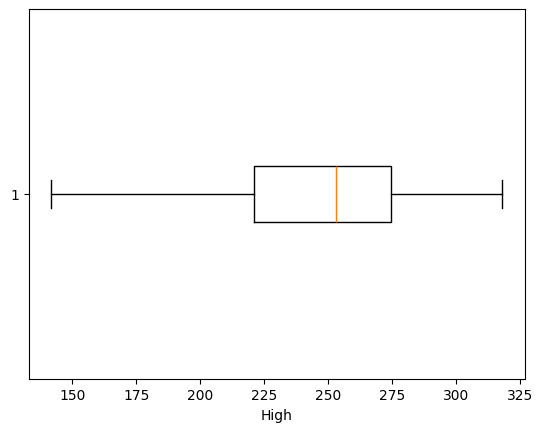

Outliers for Low: []
Number of outliers: 0


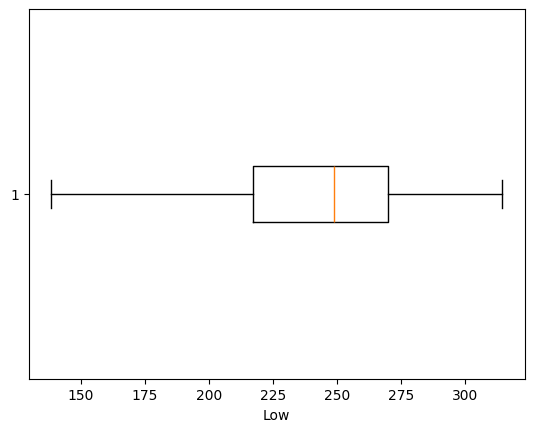

Outliers for Close: []
Number of outliers: 0


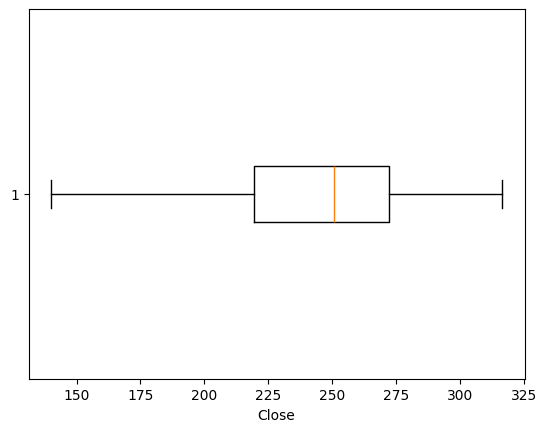

Outliers for Adj Close: []
Number of outliers: 0


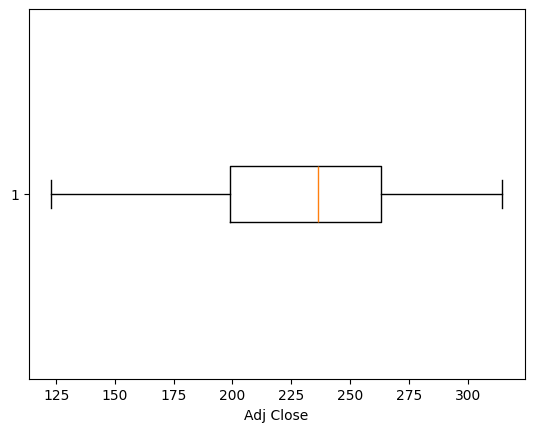

Outliers for Volume: []
Number of outliers: 0


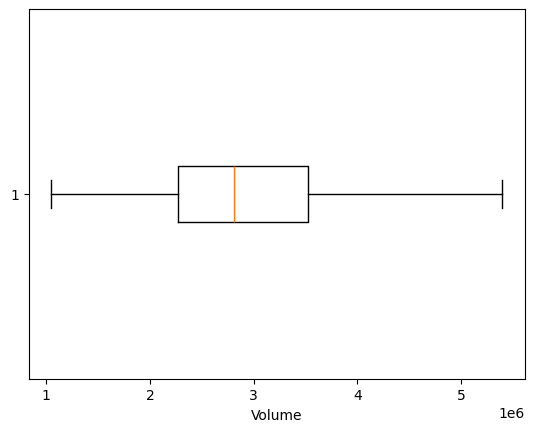

In [11]:
# Capping outliers

# Cap Low
def wisker(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3 - q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    return lower, upper

for i in ["Close", "Low", "Open", "Volume"]:
    lb, ub = wisker(data[i])
    data[i] = np.where(data[i]<lb, lb, data[i])
    data[i] = np.where(data[i]>ub, ub, data[i])

# Show boxplot again
for j in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]: 
    plt.figure()
    last_box = plt.boxplot(data[j], vert=False)
    plt.xlabel(j)

    last_outliers = last_box["fliers"][0].get_xdata()
    print(f"Outliers for {j}: {last_outliers}\nNumber of outliers: {len(last_outliers)}")
    
    plt.show()

In [12]:
data.info()
data = data.reset_index()
data.to_csv("Preprocessed_MCD.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-11-01 to 2024-10-31
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, MCD)  1258 non-null   float64
 1   (Close, MCD)      1258 non-null   float64
 2   (High, MCD)       1258 non-null   float64
 3   (Low, MCD)        1258 non-null   float64
 4   (Open, MCD)       1258 non-null   float64
 5   (Volume, MCD)     1258 non-null   float64
dtypes: float64(6)
memory usage: 68.8 KB


In [ ]:
#Save preprocessed data into .csv files
pre_df = pd.read_csv("Preprocessed_MCD.csv")
pre_df = pre_df.drop(0)
pre_df.to_csv("Preprocessed_MCD.csv", index=False)

Split the data to 80% Training, 10% Validation, 10% Testing

In [ ]:
from sklearn.model_selection import train_test_split
#Sort the data by date 
if 'Date' in data.columns:
    data = data.sort_values(by='Date')

#Split the data into training (80%) and temp (20%) for validation and test
train_data, temp_data = train_test_split(data, test_size=0.2, shuffle=False)

#Further split temp data into validation (10%) and test (10%)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

In [ ]:
#Save separately into .csv files
train_data.to_csv("MCD_train_data.csv", index=False)
validation_data.to_csv("MCD_validation_data.csv", index=False)
test_data.to_csv("MCD_test_data.csv", index=False)

print("Data split and saved successfully!")

Data split and saved successfully!


In [16]:
#delete the row filled with "MCD,"MCD"
pre_train = pd.read_csv("MCD_train_data.csv")
pre_train = pre_train.drop(0)
pre_train.to_csv("MCD_train_data.csv", index=False)

pre_validation = pd.read_csv("MCD_validation_data.csv")
pre_validation = pre_validation.drop(0)
pre_validation.to_csv("MCD_validation_data.csv", index=False)

pre_test = pd.read_csv("MCD_test_data.csv")
pre_test = pre_test.drop(0)
pre_test.to_csv("MCD_test_data.csv", index=False)